# HuBERT Embedding Pipeline — PD / HC

Full pipeline: **Extract → Aggregate → Linear Probe → Visualize**

Code structure mirrors `external/fairseq/examples/hubert/simple_kmeans/dump_hubert_feature.py`
(HubertFeatureReader class) with references noted inline.

In [1]:
import subprocess, sys
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "torch", "torchaudio", "transformers", "scipy",
     "scikit-learn", "tqdm", "matplotlib", "soundfile"],
    check=True
)
print("All packages ready.")

All packages ready.


In [2]:
import csv, glob, os
from math import gcd

import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import torch
import tqdm
from scipy.signal import resample_poly
from torch import nn
from transformers import HubertModel, Wav2Vec2FeatureExtractor

CLASSES   = ["PD", "HC"]
SEGMENTS  = ["early", "middle", "late"]
TARGET_SR = 16_000

ROOT      = os.path.abspath(os.path.join(os.getcwd(), ".."))
SEG_ROOT  = os.path.join(ROOT,        "segments")
EMB_ROOT  = os.path.join(os.getcwd(), "embeddings")
AGG_ROOT  = os.path.join(os.getcwd(), "embeddings_aggregated")
META_PATH = os.path.join(os.getcwd(), "metadata.csv")
META_AGG  = os.path.join(os.getcwd(), "metadata_aggregated.csv")
PLOTS_DIR = os.path.join(os.getcwd(), "plots")

print(f"Segments root : {SEG_ROOT}")
print(f"Embeddings out: {EMB_ROOT}")

Segments root : /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/segments
Embeddings out: /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/HuBERT/embeddings


In [3]:
# Adapted from:
#   dump_hubert_feature.py  HubertFeatureReader.read_audio()
#
# Original:
#   wav, sr = sf.read(path)
#   if wav.ndim == 2:
#       wav = wav.mean(-1)
#   assert sr == self.task.cfg.sample_rate, sr
#
# Changes:
#   - resample_poly to 16 kHz  (mPower FLAC files are 44.1 kHz)
#   - always_2d=True for safe mono mix

def read_audio(fname: str) -> tuple[np.ndarray, int]:
    wav, sr = sf.read(fname, always_2d=True)
    if wav.shape[1] > 1:
        wav = wav.mean(axis=1)
    else:
        wav = wav[:, 0]
    wav = wav.astype(np.float32)
    if sr != TARGET_SR:
        g   = gcd(sr, TARGET_SR)
        wav = resample_poly(wav, TARGET_SR // g, sr // g).astype(np.float32)
    return wav, TARGET_SR

_wav, _sr = read_audio(next(
    p for c in CLASSES for s in SEGMENTS
    for p in glob.glob(os.path.join(SEG_ROOT, c, s, "*.flac"))[:1]
))
print(f"read_audio OK  shape={_wav.shape}  sr={_sr}")

read_audio OK  shape=(48000,)  sr=16000


In [4]:
# Adapted from:
#   dump_hubert_feature.py  HubertFeatureReader.__init__() + get_feats()
#
# Original (fairseq):
#   L30  model, cfg, task = fairseq.checkpoint_utils.load_model_ensemble_and_task([ckpt_path])
#   L31  self.model = model[0].eval().cuda()
#   L38  feat, _ = self.model.extract_features(
#               source=x_chunk, padding_mask=None,
#               mask=False, output_layer=self.layer)
#
# HuggingFace equivalent:
#   HubertModel.from_pretrained(model_name)         <- replaces fairseq checkpoint load
#   Wav2Vec2FeatureExtractor                        <- handles normalisation / padding
#   outputs.last_hidden_state  [B, T, 768]          <- transformer output (layer 12 = c)
#
# NOTE: HubertModel (HuggingFace) does NOT expose extract_features in BaseModelOutput.
# Unlike Wav2Vec2Model, the CNN features are internal only.
# Since use_feat=False throughout this pipeline, only c (last_hidden_state) is used.
# z is returned as a zero placeholder to keep the same (z, c) interface.

class PretrainedHuBERTModel(nn.Module):
    def __init__(self, model_name_or_path: str):
        super().__init__()
        self.feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name_or_path)
        self.model = HubertModel.from_pretrained(model_name_or_path)
        self.model.eval()

    def forward(self, wav: np.ndarray, sr: int):
        inputs = self.feature_extractor(
            wav, sampling_rate=sr, return_tensors="pt", padding=True
        )
        input_values = inputs.input_values.to(
            next(self.model.parameters()).device
        )
        with torch.no_grad():
            outputs = self.model(input_values)
        c = outputs.last_hidden_state.squeeze(0).cpu().numpy()    # transformer [T, 768]
        z = np.zeros((c.shape[0], 512), dtype=np.float32)        # placeholder  (not used)
        return z, c

print("PretrainedHuBERTModel defined.")

PretrainedHuBERTModel defined.


In [5]:
# Mirrors HubertFeatureReader structure:
#   __init__  L30-34  load model + move to device
#   get_feats L37-50  run inference, return features
#
# Our Prediction class wraps PretrainedHuBERTModel the same way
# wav2vec_featurize.py wraps PretrainedWav2VecModel.

class Prediction:
    def __init__(self, model_name_or_path: str, gpu: int = 0):
        self.device = f"cuda:{gpu}" if torch.cuda.is_available() else "cpu"
        self.model  = PretrainedHuBERTModel(model_name_or_path)
        self.model.to(self.device)

    def __call__(self, wav: np.ndarray, sr: int):
        return self.model(wav, sr)

print("Prediction defined.")

Prediction defined.


In [6]:
# Class structure mirrors:
#   wav2vec_featurize.py  EmbeddingDatasetWriter  L111-220
#
# Identical method names preserved:
#   _progress            L151-154
#   require_output_path  L156-158  -> require_output_dirs
#   input_fnames         L189-191
#   write_features       L196-214  (with resume logic added)
#   __repr__             L216-220
#
# HuBERT-specific: model swapped to PretrainedHuBERTModel
# Output format: same .npy mean-pool + _seq.npy full sequence

class EmbeddingDatasetWriter:
    def __init__(self, input_root, output_root, model_fname,
                 gpu=0, verbose=True, use_feat=False):
        assert os.path.isdir(input_root), f"Not found: {input_root}"
        self.input_root  = input_root
        self.output_root = output_root
        self.model_fname = model_fname
        self.verbose     = verbose
        self.use_feat    = use_feat
        self.model       = Prediction(model_fname, gpu)
        self.metadata    = []

    def _progress(self, iterable, **kwargs):
        return tqdm.tqdm(iterable, **kwargs) if self.verbose else iterable

    def _input_fnames(self, cls, seg):
        return sorted(glob.glob(os.path.join(self.input_root, cls, seg, "*.flac")))

    def _output_dir(self, cls, seg):
        return os.path.join(self.output_root, cls, seg)

    def require_output_dirs(self):
        for cls in CLASSES:
            for seg in SEGMENTS:
                os.makedirs(self._output_dir(cls, seg), exist_ok=True)

    def write_features(self):
        for cls in CLASSES:
            for seg in SEGMENTS:
                fnames  = self._input_fnames(cls, seg)
                out_dir = self._output_dir(cls, seg)
                skipped = 0
                for fpath in self._progress(fnames, desc=f"{cls}/{seg}", unit="file"):
                    stem          = os.path.splitext(os.path.basename(fpath))[0]
                    mean_path     = os.path.join(out_dir, f"{stem}.npy")
                    seq_path      = os.path.join(out_dir, f"{stem}_seq.npy")
                    original_stem = "_".join(stem.split("_")[:-1])

                    if os.path.isfile(mean_path) and os.path.isfile(seq_path):
                        skipped += 1
                        self.metadata.append({
                            "filename": os.path.basename(fpath), "class": cls,
                            "segment": seg, "original_stem": original_stem,
                            "embedding_path": mean_path, "seq_path": seq_path,
                        })
                        continue

                    wav, sr  = read_audio(fpath)
                    z, c     = self.model(wav, sr)
                    features = z if self.use_feat else c
                    mean_vec = features.mean(axis=0)
                    np.save(mean_path, mean_vec)
                    np.save(seq_path,  features)
                    self.metadata.append({
                        "filename": os.path.basename(fpath), "class": cls,
                        "segment": seg, "original_stem": original_stem,
                        "embedding_path": mean_path, "seq_path": seq_path,
                    })

                if skipped:
                    print(f"  {cls}/{seg}: {skipped} files already done, skipped.")

    def write_metadata(self, path):
        fields = ["filename","class","segment","original_stem","embedding_path","seq_path"]
        with open(path, "w", newline="") as f:
            w = csv.DictWriter(f, fieldnames=fields)
            w.writeheader(); w.writerows(self.metadata)
        print(f"Metadata  ->  {path}")

    def __repr__(self):
        n = sum(len(self._input_fnames(c, s)) for c in CLASSES for s in SEGMENTS)
        return (f"EmbeddingDatasetWriter ({n} files)\n"
                f"\tinput_root  : {self.input_root}\n"
                f"\toutput_root : {self.output_root}\n"
                f"\tmodel       : {self.model_fname}")

print("EmbeddingDatasetWriter defined (resume-enabled).")

EmbeddingDatasetWriter defined (resume-enabled).


## Step 1 — Extract Embeddings

Mirrors `dump_hubert_feature.py` main execution block.

Original loops over dataset splits; here one writer walks all CLASSES × SEGMENTS.  
Model: `facebook/hubert-base-ls960` — HuBERT base pretrained on LibriSpeech 960h.

In [7]:
MODEL = "facebook/hubert-base-ls960"

writer = EmbeddingDatasetWriter(
    input_root  = SEG_ROOT,
    output_root = EMB_ROOT,
    model_fname = MODEL,
    gpu         = 0,
    use_feat    = False,   # False = use last_hidden_state [768-d]; True = CNN features [512-d]
)
print(writer)
writer.require_output_dirs()

print("\nExtracting embeddings...")
writer.write_features()
print("Done.\n")

writer.write_metadata(META_PATH)

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

EmbeddingDatasetWriter (3741 files)
	input_root  : /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/segments
	output_root : /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/HuBERT/embeddings
	model       : facebook/hubert-base-ls960

Extracting embeddings...


PD/early:   0%|                                                                                                                                                                               | 0/338 [00:00<?, ?file/s]

PD/early:   0%|▍                                                                                                                                                                      | 1/338 [00:00<01:19,  4.25file/s]

PD/early:   1%|▉                                                                                                                                                                      | 2/338 [00:00<01:13,  4.54file/s]

...

HC/late: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋| 907/909 [04:08<00:00,  3.75file/s]

HC/late: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊| 908/909 [04:09<00:00,  3.63file/s]

HC/late: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 909/909 [04:09<00:00,  3.52file/s]

HC/late: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 909/909 [04:09<00:00,  3.64file/s]

Done.

Metadata  ->  /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/HuBERT/metadata.csv


## Step 2 — Aggregate Segment Embeddings

Combine `early / middle / late` vectors for each original recording.  
- `concat` → 3 × 768 = **2304-d** vector  
- `mean`   → **768-d** vector

In [8]:
import pandas as pd

def load_seg_emb(root, cls, seg, stem):
    path = os.path.join(root, cls, seg, f"{stem}.npy")
    if not os.path.isfile(path):
        raise FileNotFoundError(path)
    return np.load(path)

def run_aggregation(emb_root, agg_root, strategy="concat"):
    os.makedirs(agg_root, exist_ok=True)
    records = []
    for cls in CLASSES:
        early_dir = os.path.join(emb_root, cls, "early")
        stems = sorted(
            os.path.splitext(f)[0].removesuffix("_early")
            for f in os.listdir(early_dir)
            if f.endswith(".npy") and not f.endswith("_seq.npy")
        )
        out_cls = os.path.join(agg_root, cls)
        os.makedirs(out_cls, exist_ok=True)
        for orig_stem in tqdm.tqdm(stems, desc=cls, unit="file"):
            vecs, skip = [], False
            for seg in SEGMENTS:
                try:
                    vecs.append(load_seg_emb(emb_root, cls, seg, f"{orig_stem}_{seg}"))
                except FileNotFoundError:
                    skip = True; break
            if skip:
                continue
            agg = np.concatenate(vecs) if strategy == "concat" else np.stack(vecs).mean(0)
            out = os.path.join(out_cls, f"{orig_stem}_{strategy}.npy")
            np.save(out, agg)
            records.append({
                "original_stem":  orig_stem,
                "class":          cls,
                "strategy":       strategy,
                "embedding_dim":  agg.shape[0],
                "embedding_path": out,
            })
    return pd.DataFrame(records)

agg_df = run_aggregation(EMB_ROOT, AGG_ROOT, strategy="concat")
agg_df.to_csv(META_AGG, index=False)
print(f"Aggregated {len(agg_df)} recordings  ->  {META_AGG}")

PD:   0%|                                                                                                                                                                                     | 0/338 [00:00<?, ?file/s]

PD:  37%|██████████████████████████████████████████████████████████████▌                                                                                                          | 125/338 [00:00<00:00, 1241.36file/s]

PD:  89%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                   | 300/338 [00:00<00:00, 1535.54file/s]

PD: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 338/338 [00:00<00:00, 1508.41file/s]

HC:   0%|                                                                                                                                                                                     | 0/909 [00:00<?, ?file/s]

...

HC:  54%|██████████████████████████████████████████████████████████████████████████████████████████▌                                                                              | 487/909 [00:00<00:00, 1661.00file/s]

HC:  72%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                               | 654/909 [00:00<00:00, 1485.70file/s]

HC:  89%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                   | 806/909 [00:00<00:00, 1459.06file/s]

HC: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 909/909 [00:00<00:00, 1458.53file/s]

Aggregated 1247 recordings  ->  /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/HuBERT/metadata_aggregated.csv


## Step 3 — Linear Probe

5-fold stratified cross-validation with `StandardScaler + LogisticRegression`.  
One probe per segment + one on the aggregated 2304-d vectors.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def load_X_y(df, segment=None):
    if segment is not None:
        df = df[df["segment"] == segment]
    X, y = [], []
    for _, row in df.iterrows():
        p = row["embedding_path"]
        if os.path.isfile(p):
            X.append(np.load(p))
            y.append(1 if row["class"] == "PD" else 0)
    if not X:
        return np.empty((0,)), np.empty((0,))
    return np.stack(X), np.array(y)

def probe(X, y, label, n_splits=5):
    pipe   = Pipeline([("sc", StandardScaler()),
                       ("clf", LogisticRegression(max_iter=1000, solver="lbfgs",
                                                  class_weight="balanced"))])
    skf    = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    y_pred = cross_val_predict(pipe, X, y, cv=skf)
    acc    = accuracy_score(y, y_pred)
    print(f"\n{'='*52}\nProbe : {label:<28} Acc = {acc:.4f}")
    print(classification_report(y, y_pred, target_names=["HC", "PD"]))
    return acc

meta_df = pd.read_csv(META_PATH)
results = {}
for seg in SEGMENTS:
    X, y = load_X_y(meta_df, segment=seg)
    if len(X):
        results[seg] = probe(X, y, label=seg)

X_agg, y_agg = load_X_y(agg_df)
if len(X_agg):
    results["aggregated"] = probe(X_agg, y_agg, label="aggregated (concat)")

print("\nSummary")
print("-" * 35)
for k, v in results.items():
    print(f"  {k:<22} {v*100:.2f}%")
if results:
    best = max(results, key=results.get)
    print(f"\n  Best : {best}  ({results[best]*100:.2f}%)")


Probe : early                        Acc = 0.7289
              precision    recall  f1-score   support

          HC       0.83      0.79      0.81       909
          PD       0.50      0.57      0.53       338

    accuracy                           0.73      1247
   macro avg       0.67      0.68      0.67      1247
weighted avg       0.74      0.73      0.73      1247




Probe : middle                       Acc = 0.7281
              precision    recall  f1-score   support

          HC       0.83      0.79      0.81       909
          PD       0.50      0.57      0.53       338

    accuracy                           0.73      1247
   macro avg       0.67      0.68      0.67      1247
weighted avg       0.74      0.73      0.73      1247




Probe : late                         Acc = 0.6832
              precision    recall  f1-score   support

          HC       0.79      0.77      0.78       909
          PD       0.42      0.45      0.44       338

    accuracy                           0.68      1247
   macro avg       0.61      0.61      0.61      1247
weighted avg       0.69      0.68      0.69      1247




Probe : aggregated (concat)          Acc = 0.7610
              precision    recall  f1-score   support

          HC       0.84      0.83      0.83       909
          PD       0.56      0.58      0.57       338

    accuracy                           0.76      1247
   macro avg       0.70      0.71      0.70      1247
weighted avg       0.76      0.76      0.76      1247


Summary
-----------------------------------
  early                  72.89%
  middle                 72.81%
  late                   68.32%
  aggregated             76.10%

  Best : aggregated  (76.10%)


## Step 4 — Visualization (t-SNE)

Reduce mean-pooled embeddings to 2-D and plot coloured by class and by segment.

Running t-SNE on 3741 embeddings (dim=768)...


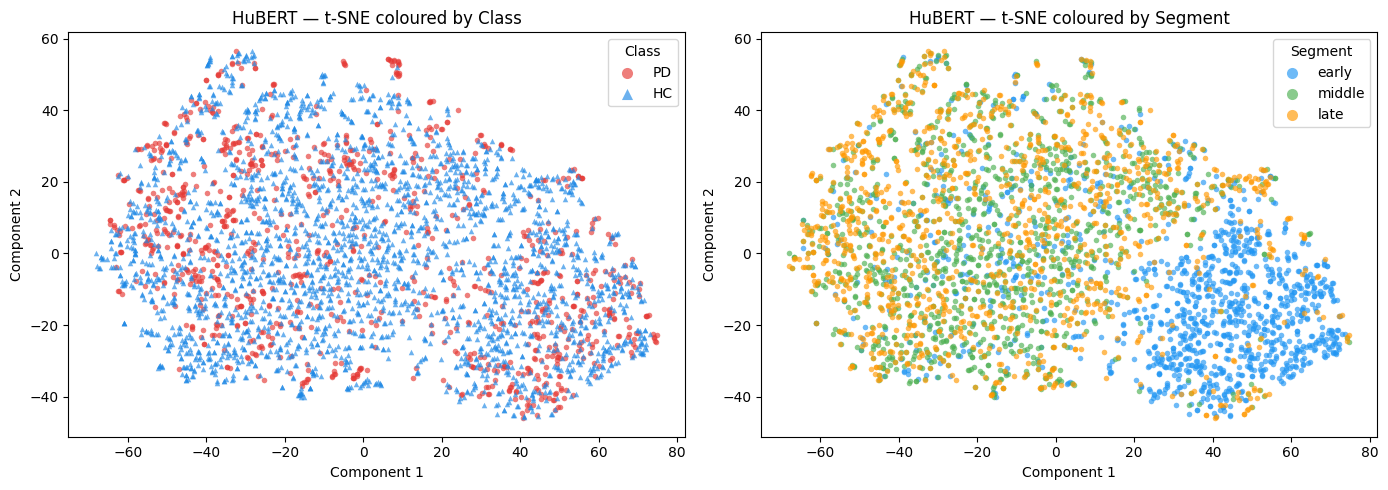


Plot saved  ->  /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/HuBERT/plots/tsne_combined.png


In [10]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler as SS

CLASS_COLORS  = {"PD": "#E53935", "HC": "#1E88E5"}
CLASS_MARKERS = {"PD": "o",       "HC": "^"}
SEG_COLORS    = {"early": "#2196F3", "middle": "#4CAF50", "late": "#FF9800"}

def load_for_viz(df):
    X, labels, segs = [], [], []
    for _, row in df.iterrows():
        p = row["embedding_path"]
        if os.path.isfile(p):
            X.append(np.load(p))
            labels.append(row["class"])
            segs.append(row.get("segment", "agg"))
    return np.stack(X), np.array(labels), np.array(segs)

meta_df = pd.read_csv(META_PATH)
X, labels, segs = load_for_viz(meta_df)
print(f"Running t-SNE on {len(X)} embeddings (dim={X.shape[1]})...")

coords = TSNE(
    n_components=2, perplexity=30, random_state=42,
    init="pca", max_iter=1000
).fit_transform(SS().fit_transform(X))

os.makedirs(PLOTS_DIR, exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls in ["PD", "HC"]:
    m = labels == cls
    axes[0].scatter(coords[m, 0], coords[m, 1],
                    label=cls, alpha=0.65, s=16,
                    color=CLASS_COLORS[cls], marker=CLASS_MARKERS[cls], linewidths=0)
axes[0].set_title("HuBERT — t-SNE coloured by Class")
axes[0].set_xlabel("Component 1"); axes[0].set_ylabel("Component 2")
axes[0].legend(title="Class", markerscale=2)

for seg in SEGMENTS:
    m = segs == seg
    axes[1].scatter(coords[m, 0], coords[m, 1],
                    label=seg, alpha=0.65, s=16,
                    color=SEG_COLORS[seg], linewidths=0)
axes[1].set_title("HuBERT — t-SNE coloured by Segment")
axes[1].set_xlabel("Component 1"); axes[1].set_ylabel("Component 2")
axes[1].legend(title="Segment", markerscale=2)

plt.tight_layout()
out = os.path.join(PLOTS_DIR, "tsne_combined.png")
plt.savefig(out, dpi=150)
plt.show()
print(f"\nPlot saved  ->  {out}")